Memulai Proses Evolusi...

Gen   1 : Max Fitness =  10.00 | Avg Fitness =   6.56
Gen   2 : Max Fitness =  11.11 | Avg Fitness =   6.83
Gen   3 : Max Fitness =  11.11 | Avg Fitness =   6.97
Gen   4 : Max Fitness =  11.11 | Avg Fitness =   7.30
Gen   5 : Max Fitness =  11.11 | Avg Fitness =   6.96
Gen   6 : Max Fitness =  11.11 | Avg Fitness =   7.10
Gen   7 : Max Fitness =  11.11 | Avg Fitness =   7.31
Gen   8 : Max Fitness =  11.11 | Avg Fitness =   7.55
Gen   9 : Max Fitness =  11.11 | Avg Fitness =   7.42
Gen  10 : Max Fitness =  14.29 | Avg Fitness =   7.71
Gen  20 : Max Fitness =  20.00 | Avg Fitness =   8.75
Gen  30 : Max Fitness =  20.00 | Avg Fitness =   7.61
Gen  40 : Max Fitness =  33.33 | Avg Fitness =   8.16
Gen  50 : Max Fitness =  33.33 | Avg Fitness =   8.34
Gen  60 : Max Fitness =  33.33 | Avg Fitness =  10.12
Gen  70 : Max Fitness =  33.33 | Avg Fitness =   9.06
Gen  80 : Max Fitness =  33.33 | Avg Fitness =   9.13
Gen  90 : Max Fitness =  33.33 | Avg Fitness =   8.61
G

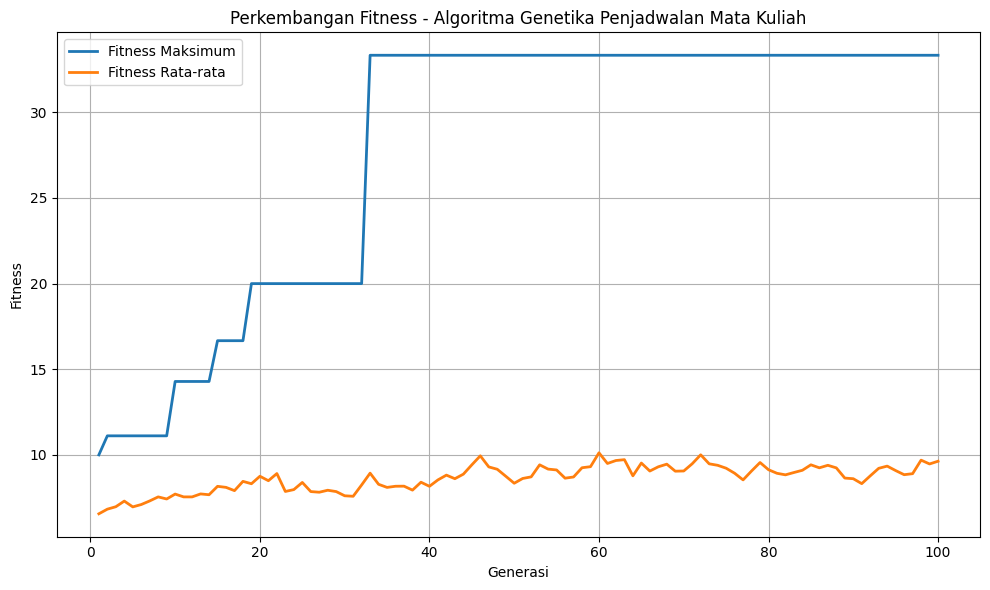

In [1]:
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA INPUT & PARAMETER ALGORITMA
# ==========================================

courses = [
    ("AI", "DosenA"), ("ML", "DosenB"), ("DB", "DosenC"), ("CN", "DosenD"),
    ("SE", "DosenE"), ("OS", "DosenF"), ("IR", "DosenA"), ("NLP", "DosenB"),
    ("CV", "DosenC"), ("IOT", "DosenD"), ("HCI", "DosenE"), ("CyberSec", "DosenF"),
    ("BigData", "DosenA"), ("DL", "DosenB"), ("NoSQL", "DosenC"), ("Cloud", "DosenD"),
    ("UX", "DosenE"), ("SecEng", "DosenF"), ("Agile", "DosenA"), ("RL", "DosenB"),
    ("ETL", "DosenC"), ("DevOps", "DosenD"), ("GameDev", "DosenE"), ("Blockchain", "DosenF")
]

rooms = ["R1", "R2", "R3", "R4"]

timeslots = [
    "Senin-08", "Senin-10", "Senin-13",
    "Selasa-08", "Selasa-10", "Selasa-13",
    "Rabu-08", "Rabu-10", "Rabu-13",
    "Kamis-08", "Kamis-10", "Kamis-13"
]

POPULATION_SIZE = 60
MAX_GENERATIONS = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.20

# Helper untuk memisahkan Hari dan Jam dari slot waktu
def parse_timeslot(ts):
    day, time = ts.split("-")
    return day, time

# ==========================================
# 2. EVALUASI FITNESS & KONFLIK
# ==========================================

def calculate_fitness_and_conflicts(individual):
    """
    Menghitung jumlah konflik berdasarkan 3 aturan:
    1. Konflik Ruang: Dua MK di ruangan & slot waktu yang sama.
    2. Konflik Dosen-Waktu: Dosen mengajar >1 MK di slot waktu yang sama.
    3. Konflik Dosen-Hari: Dosen mengajar >1 kali pada hari yang sama.

    Skala Fitness: 0 - 100 (100 / (1 + total_konflik))
    """
    konflik_ruang = 0
    konflik_dosen_waktu = 0
    konflik_dosen_hari = 0

    # 1. Evaluasi Konflik Ruang & Dosen-Waktu
    room_time_map = {}
    dosen_time_map = {}
    dosen_day_map = {}

    for i, gen in enumerate(individual):
        mk, dosen = courses[i]
        room = gen["room"]
        timeslot = gen["timeslot"]
        day, _ = parse_timeslot(timeslot)

        # Cek Konflik Ruang
        rt_key = (room, timeslot)
        if rt_key in room_time_map:
            konflik_ruang += 1
        else:
            room_time_map[rt_key] = True

        # Cek Konflik Dosen-Waktu
        dt_key = (dosen, timeslot)
        if dt_key in dosen_time_map:
            konflik_dosen_waktu += 1
        else:
            dosen_time_map[dt_key] = True

        # Catat Hari Mengajar Dosen
        if dosen not in dosen_day_map:
            dosen_day_map[dosen] = []
        dosen_day_map[dosen].append(day)

    # 2. Evaluasi Konflik Dosen-Hari (>1 kali mengajar pada hari yang sama)
    for dosen, days in dosen_day_map.items():
        day_counts = {}
        for d in days:
            day_counts[d] = day_counts.get(d, 0) + 1

        for d, count in day_counts.items():
            if count > 1:
                konflik_dosen_hari += (count - 1)

    total_konflik = konflik_ruang + konflik_dosen_waktu + konflik_dosen_hari

    # Skala fitness 0 - 100
    fitness = 100.0 / (1.0 + total_konflik)

    return fitness, total_konflik

# ==========================================
# 3. OPERATOR GENETIKA
# ==========================================

def create_individual():
    """Membuat 1 individu yang terdiri dari 24 gen."""
    individual = []
    for _ in courses:
        gen = {
            "room": random.choice(rooms),
            "timeslot": random.choice(timeslots)
        }
        individual.append(gen)
    return individual

def selection(population, fitnesses):
    """Seleksi orang tua menggunakan Tournament Selection."""
    tournament_size = 3
    selected = random.sample(list(zip(population, fitnesses)), tournament_size)
    selected.sort(key=lambda x: x[1], reverse=True)
    return selected[0][0]

def crossover(parent1, parent2):
    """Single-point crossover berdasarkan Crossover Rate."""
    if random.random() < CROSSOVER_RATE:
        point = random.randint(1, len(courses) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    return parent1.copy(), parent2.copy()

def mutate(individual):
    """Mutasi gen secara acak berdasarkan Mutation Rate."""
    mutated = []
    for gen in individual:
        new_gen = gen.copy()
        if random.random() < MUTATION_RATE:
            new_gen["room"] = random.choice(rooms)
        if random.random() < MUTATION_RATE:
            new_gen["timeslot"] = random.choice(timeslots)
        mutated.append(new_gen)
    return mutated

# ==========================================
# 4. PROSES EVOLUSI MAIN LOOP
# ==========================================

# Inisialisasi Populasi Awal
population = [create_individual() for _ in range(POPULATION_SIZE)]

max_fitness_history = []
avg_fitness_history = []

best_overall_individual = None
best_overall_fitness = -1
best_overall_conflicts = float('inf')

print("Memulai Proses Evolusi...\n")

for gen in range(1, MAX_GENERATIONS + 1):
    fitness_results = [calculate_fitness_and_conflicts(ind) for ind in population]
    fitnesses = [res[0] for res in fitness_results]
    conflicts = [res[1] for res in fitness_results]

    current_max_fitness = max(fitnesses)
    current_avg_fitness = sum(fitnesses) / POPULATION_SIZE

    max_fitness_history.append(current_max_fitness)
    avg_fitness_history.append(current_avg_fitness)

    # Simpan individu terbaik sepanjang masa
    best_idx = fitnesses.index(current_max_fitness)
    if current_max_fitness > best_overall_fitness:
        best_overall_fitness = current_max_fitness
        best_overall_individual = population[best_idx]
        best_overall_conflicts = conflicts[best_idx]

    # Cetak Perkembangan per Generasi (Ditampilkan 10 generasi pertama & setiap kelipatan 10)
    if gen <= 10 or gen % 10 == 0:
        print(f"Gen {gen:3d} : Max Fitness = {current_max_fitness:6.2f} | Avg Fitness = {current_avg_fitness:6.2f}")

    # Buat Populasi Baru
    new_population = []

    # Elitisme: Pertahankan 2 individu terbaik
    sorted_pop = [x for _, x in sorted(zip(fitnesses, population), key=lambda pair: pair[0], reverse=True)]
    new_population.extend(sorted_pop[:2])

    while len(new_population) < POPULATION_SIZE:
        parent1 = selection(population, fitnesses)
        parent2 = selection(population, fitnesses)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1))
        if len(new_population) < POPULATION_SIZE:
            new_population.append(mutate(child2))

    population = new_population

# ==========================================
# 5. MENAMPILKAN HASIL AKHIR
# ==========================================

print("\n=== JADWAL TERBAIK ===")
for i, gen in enumerate(best_overall_individual):
    mk, dosen = courses[i]
    print(f"MK: {mk:<10} | Ruang: {gen['room']} | Waktu: {gen['timeslot']:<10} | Dosen: {dosen}")

print("\n=== HASIL EVALUASI AKHIR ===")
print(f"Fitness Terbaik : {best_overall_fitness:.2f}")
print(f"Jumlah Konflik  : {best_overall_conflicts}")

# ==========================================
# 6. VISUALISASI GRAFIK MATPLOTLIB
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(range(1, MAX_GENERATIONS + 1), max_fitness_history, label="Fitness Maksimum", color="#1f77b4", linewidth=2)
plt.plot(range(1, MAX_GENERATIONS + 1), avg_fitness_history, label="Fitness Rata-rata", color="#ff7f0e", linewidth=2)

plt.title("Perkembangan Fitness - Algoritma Genetika Penjadwalan Mata Kuliah")
plt.xlabel("Generasi")
plt.ylabel("Fitness")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()